In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('TakeHomeCustomerDataSet_adj.csv')
df.head()

,CustomerId,OpenedDate,Age,CreditLimit,NetMonthlyIncome,PredictedProbabilityOfDefault,Actual_Value_12Month
0,1,01/10/2023,66,400,3643.0,0.099025,0.00
1,2,01/10/2023,54,100,4200.0,0.040806,0.00
2,3,01/10/2023,41,1500,3200.0,0.040239,5.88
3,4,01/10/2023,42,200,2500.0,0.051386,82.42
4,5,01/10/2023,38,800,1800.0,0.126270,0.00


In [4]:
df.shape

(7396, 7)

In [5]:
df.dtypes

CustomerId                         int64
OpenedDate                        object
Age                                int64
CreditLimit                        int64
NetMonthlyIncome                 float64
PredictedProbabilityOfDefault    float64
Actual_Value_12Month             float64
dtype: object

In [6]:
df.isna().sum()

CustomerId                       0
OpenedDate                       0
Age                              0
CreditLimit                      0
NetMonthlyIncome                 0
PredictedProbabilityOfDefault    1
Actual_Value_12Month             0
dtype: int64

In [7]:
df[df['PredictedProbabilityOfDefault'].isna()]

,CustomerId,OpenedDate,Age,CreditLimit,NetMonthlyIncome,PredictedProbabilityOfDefault,Actual_Value_12Month
6048,6049,20/11/2023,60,200,1527.0,NaN,20.69


In [8]:
df.describe()

,CustomerId,Age,CreditLimit,NetMonthlyIncome,PredictedProbabilityOfDefault,Actual_Value_12Month
count,7396.000000,7396.000000,7396.000000,7396.000000,7395.000000,7396.000000
mean,3698.500000,43.985127,538.250406,2407.384667,0.100191,27.451122
std,2135.185628,11.970904,606.817139,3946.345941,0.054239,271.265539
min,1.000000,18.000000,50.000000,-3000.000000,0.009836,-2970.560000
25%,1849.750000,35.000000,100.000000,1629.250000,0.064475,0.000000
50%,3698.500000,43.000000,200.000000,2100.000000,0.088328,30.395000
75%,5547.250000,53.000000,800.000000,2600.000000,0.122875,125.510000
max,7396.000000,75.000000,15000.000000,99999.000000,0.495918,1666.080000


suspects:
NetMonthlyIncome: min = -3000
NetMonthlyIncome: max = 99999 (way above the mean of ~2400)
CreditLimit: max = 15000, but 75th percentile is only 800

In [9]:
df[df['NetMonthlyIncome'] < 0]

,CustomerId,OpenedDate,Age,CreditLimit,NetMonthlyIncome,PredictedProbabilityOfDefault,Actual_Value_12Month
4689,4690,10/11/2023,57,800,-3000.0,0.066597,174.36


In [11]:
df[df['NetMonthlyIncome'] == 99999]

,CustomerId,OpenedDate,Age,CreditLimit,NetMonthlyIncome,PredictedProbabilityOfDefault,Actual_Value_12Month
646,647,07/10/2023,47,1000,99999.0,0.096869,36.67
690,691,08/10/2023,57,200,99999.0,0.102484,45.00
3088,3089,29/10/2023,52,400,99999.0,0.056682,0.00
3988,3989,05/11/2023,29,200,99999.0,0.075474,100.96
3995,3996,05/11/2023,56,400,99999.0,0.050395,169.69
4753,4754,10/11/2023,59,1000,99999.0,0.105243,-1277.81
5034,5035,13/11/2023,57,1000,99999.0,0.124561,254.27
6128,6129,21/11/2023,55,1500,99999.0,0.044783,0.00
7104,7105,28/11/2023,32,400,99999.0,0.226663,0.00


In [17]:
df[df['NetMonthlyIncome'] == 99999]['Actual_Value_12Month']

646       36.67
690       45.00
3088       0.00
3988     100.96
3995     169.69
4753   -1277.81
5034     254.27
6128       0.00
7104       0.00
Name: Actual_Value_12Month, dtype: float64

confirming it is probably missing value not very rich customers

In [13]:
df['CreditLimit'].value_counts().sort_index(ascending=False).head(10)

CreditLimit
15000      1
3000      70
2900       1
2500       6
2100       1
2000     432
1500     417
1400       2
1000     399
800      655
Name: count, dtype: int64

In [15]:
df[df['CreditLimit'] == 15000]

,CustomerId,OpenedDate,Age,CreditLimit,NetMonthlyIncome,PredictedProbabilityOfDefault,Actual_Value_12Month
4206,4207,07/11/2023,25,15000,2700.0,0.13661,0.0


Probably a typo , should be 1500 considering age and income

-- in the past columns we looked for missing values, investigated each suspect of data we had with describe.
Now lets handle the date to compare october and november


In [24]:
df['OpenedDate'] = pd.to_datetime(df['OpenedDate'], dayfirst=True)

In [25]:
df['Month'] = df['OpenedDate'].dt.month_name()
df['Month'].value_counts()

Month
November    3990
October     3406
Name: count, dtype: int64

In [27]:
df.groupby('Month').mean()

,CustomerId,OpenedDate,Age,CreditLimit,NetMonthlyIncome,PredictedProbabilityOfDefault,Actual_Value_12Month
Month,,,,,,,
November,5401.5,2023-11-15 12:09:23.007518720,43.774436,519.924812,2437.617905,0.100791,29.625251
October,1703.5,2023-10-16 12:53:41.608925184,44.231944,559.718144,2371.967575,0.099489,24.904213


In [28]:
df.groupby('Month')[['Age','CreditLimit','NetMonthlyIncome','PredictedProbabilityOfDefault','Actual_Value_12Month']].mean()

,Age,CreditLimit,NetMonthlyIncome,PredictedProbabilityOfDefault,Actual_Value_12Month
Month,,,,,
November,43.774436,519.924812,2437.617905,0.100791,29.625251
October,44.231944,559.718144,2371.967575,0.099489,24.904213


In [29]:
df.groupby('Month')['Actual_Value_12Month'].sum()

Month
November    118204.75
October      84823.75
Name: Actual_Value_12Month, dtype: float64

next step: Segment by PredictedProbabilityOfDefault

In [30]:
df['PD_Band'] = pd.cut(df['PredictedProbabilityOfDefault'], 
                        bins=[0, 0.05, 0.10, 0.15, 0.20, 0.5],
                        labels=['0-5%','5-10%','10-15%','15-20%','20%+'])

In [31]:
df.groupby('PD_Band')['Actual_Value_12Month'].agg(['mean','count'])

C:\Users\fares\AppData\Local\Temp\ipykernel_15604\3026282073.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('PD_Band')['Actual_Value_12Month'].agg(['mean','count'])


,mean,count
PD_Band,,
0-5%,78.083008,944
5-10%,32.137751,3544
10-15%,15.260776,1816
15-20%,-4.099013,699
20%+,-24.099745,392


value decrease as predicted risk increases? so the bank's risk model is well-calibrated

what % of each band is loss-making:

In [33]:
df.groupby('PD_Band')['Actual_Value_12Month'].apply(lambda x: (x < 0).mean())

C:\Users\fares\AppData\Local\Temp\ipykernel_15604\3892975587.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('PD_Band')['Actual_Value_12Month'].apply(lambda x: (x < 0).mean())


PD_Band
0-5%      0.102754
5-10%     0.145034
10-15%    0.179515
15-20%    0.250358
20%+      0.308673
Name: Actual_Value_12Month, dtype: float64

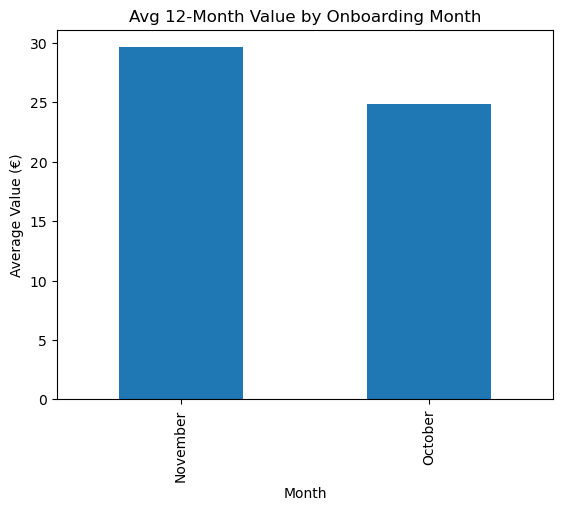

C:\Users\fares\AppData\Local\Temp\ipykernel_15604\444682369.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('PD_Band')['Actual_Value_12Month'].mean().plot(kind='bar', title='Avg 12-Month Value by Risk Band')


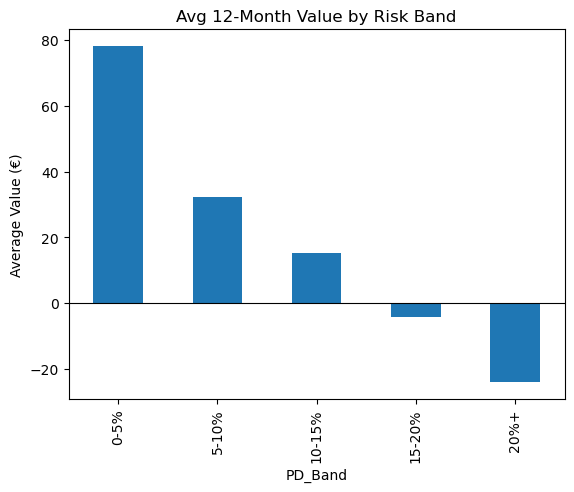

In [34]:
# Chart 1: Monthly comparison
df.groupby('Month')['Actual_Value_12Month'].mean().plot(kind='bar', title='Avg 12-Month Value by Onboarding Month')
plt.ylabel('Average Value (€)')
plt.show()

# Chart 2: PD segmentation
df.groupby('PD_Band')['Actual_Value_12Month'].mean().plot(kind='bar', title='Avg 12-Month Value by Risk Band')
plt.ylabel('Average Value (€)')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()